<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Messy%20E-Commerce%20Sales%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Messy E-Commerce Sales Dataset


## Messy E-Commerce Sales Dataset: Key Insights

This analysis delved into a somewhat chaotic e-commerce sales dataset, uncovering crucial insights across data quality, customer behavior, and sales forecasting.

### Data Overview & Cleaning
The dataset, containing 103 entries, suffered from common real-world issues: inconsistent column naming (` Customer_Name`, ` Category`), mixed data types (`Quantity`, `Price` as objects), missing values across `Category`, `Quantity`, `Price`, and `Total`, and even duplicate entries. A significant step involved stripping whitespace from column names and standardizing text-based columns like `Status` and `Payment_Method`. Crucially, `Quantity` and `Price` were coerced into numeric types, and the `Total` column was re-audited (`Total_Audited = Quantity * Price`) to correct accounting discrepancies and handle invalid entries. Rows with critical missing transaction details were removed, resulting in a cleaner, more reliable dataset for further analysis.

### Exploratory Data Analysis (EDA)
Univariate analysis revealed value counts for categorical columns: 'Books' and 'Home' were the most frequent categories, '5' was the most common quantity, and 'Cash on Delivery' was the most popular payment method, followed closely by PayPal, Bank Transfer, and Credit Card. 'Processing' and 'Returned' were the most frequent order statuses. Numerical distributions were examined, and correlations between numerical features were visualized.

Bivariate and Multivariate analyses further explored relationships. Scatter plots showed interactions between numerical features, while box plots illustrated the distribution of numerical values across different categories. Heatmaps provided insights into the dependencies between categorical variables, showing, for example, that certain payment methods might be more frequently associated with particular statuses.

### Statistical Insights
*   **The Fulfillment Paradox**: A Chi-Square Test of Independence was conducted to see if the `Payment_Method` influenced the `Status` of an order (e.g., successful vs. cancelled). The p-value of 7.15e-01 indicated no statistically significant relationship. This means, surprisingly, that the payment gateway used does not statistically impact whether an order is successfully fulfilled or cancelled in this dataset.
*   **Category Elasticity**: A Kruskal-Wallis H-Test assessed whether transaction `Total_Audited` differed significantly across various `Category` types. With a p-value of 1.26e-01, no statistical difference was found. This implies that, from a statistical distribution perspective, all product categories in this dataset generate a similar range of revenue per transaction.

### Time-Series Forecasting
After aggregating daily Gross Merchandise Value (GMV), a Holt-Winters Exponential Smoothing model was applied to forecast the next 30 days of sales. The forecast projected a significant **34.98% decrease** in average daily GMV. This is a critical alert, suggesting a need to audit marketing spend and inventory holding costs to prepare for the anticipated downturn.

### Machine Learning for Fulfillment Prediction
A classification task was undertaken to predict `Is_Successful` (whether an order is completed or failed/cancelled). Features like `ID`, `Customer_Name`, `Order_ID`, `Order_Date`, `Status`, `Total`, `Total_Audited`, and `Product` were carefully removed to prevent target leakage. Categorical features (`Category`, `Payment_Method`) were one-hot encoded, and numerical features (`Quantity`, `Price`) were standardized. Both Random Forest and XGBoost classifiers were trained.

Remarkably, both models achieved **100% accuracy, precision, recall, and F1-score** on the unseen test set. This perfect performance, while impressive, suggests that the patterns distinguishing successful from failed orders are extremely clear in this dataset, or there might be an issue like data leakage. However, based on the metrics, the models are highly effective. The feature importance analysis, though, showed zero importance for all features, which is contradictory to the perfect score and warrants further investigation into the model or data properties.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d kandeelai22/messy-e-commerce-sales-dataset

# Unziping the downloaded file
!unzip messy-e-commerce-sales-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kandeelai22/messy-e-commerce-sales-dataset
License(s): CC0-1.0
100% 3.06k/3.06k [00:00<00:00, 5.57MB/s]

Archive:  messy-e-commerce-sales-dataset.zip
  inflating: messy_ecommerce_sales_data.csv  


In [3]:
df = pd.read_csv('messy_ecommerce_sales_data.csv')
df.head(11)

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51
5,105,Customer_105,ORD-22442,11/20/2024,Tennis Racket,Sports,3,122.06,Cash on Delivery,Cancelled,366.18
6,106,Customer_106,ORD-25885,2/2/2025,Blender,Home,NaN,978.63,Bank Transfer,Processing,NaN
7,107,Customer_107,ORD-89122,1/3/2025,Biography,Books,5,587.68,PayPal,Returned,2938.40
8,108,Customer_108,ORD-64400,10/23/2025,Science,Books,1,600.29,Cash on Delivery,Processing,600.29
9,109,Customer_109,ORD-18512,5/3/2025,Tennis Racket,Sports,5,168.34,Credit Card,Shipped,841.70


In [4]:
df.tail(11)

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
92,192,Customer_192,ORD-35144,abc,Jacket,Clothing,4a,203.63,Credit Card,Returned,NaN
93,193,Customer_193,ORD-42475,6/6/2025,Basketball,NaN,NaN,522.02,PayPal,Shipped,NaN
94,194,Customer_194,ORD-69764,2/10/2025,Lamp,Home,5,944.54,Cash on Delivery,Returned,4722.700
95,195,Customer_195,ORD-82876,6/19/2025,Biography,Books,5,817.46,Cash on Delivery,Returned,4087.300
96,196,Customer_196,ORD-78384,12/23/2024,Vacuum,Home,NaN,abd,PayPal,Delivered,NaN
97,197,Customer_197,ORD-79139,6/23/2025,Blender,Home,1,160.16,PayPal,Cancelled,160.160
98,198,Customer_198,ORD-14608,7/27/2025,Vacuum,NaN,2,497.01,Cash on Delivery,Shipped,994.020
99,199,Customer_199,ORD-82922,1/22/2025,Blender,Home,5,372.28,Credit Card,Shipped,1861.400
100,175,Customer_175,ORD-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,77.952
101,142,Customer_142,ORD-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.300


In [5]:
df.shape

(103, 11)

In [7]:
df.columns

Index(['ID', ' Customer_Name', 'Order_ID', 'Order_Date', 'Product',
       ' Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total'],
      dtype='object')

In [8]:
df.dtypes

,0
ID,int64
Customer_Name,object
Order_ID,object
Order_Date,object
Product,object
Category,object
Quantity,object
Price,object
Payment_Method,object
Status,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    object 
 2   Order_ID        103 non-null    object 
 3   Order_Date      103 non-null    object 
 4   Product         103 non-null    object 
 5    Category       95 non-null     object 
 6   Quantity        98 non-null     object 
 7   Price           98 non-null     object 
 8   Payment_Method  103 non-null    object 
 9   Status          103 non-null    object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.0+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,103.0,NaN,NaN,NaN,149.640777,28.704326,100.0,125.5,149.0,174.5,199.0
Customer_Name,103,100,Customer_146,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_ID,103,100,ORD-32755,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,103,86,2/9/2025,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,103,21,Blender,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,95,9,Books,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,98,8,5,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,98,94,abd,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Method,103,4,Cash on Delivery,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,103,5,Processing,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

,0
ID,0
Customer_Name,0
Order_ID,0
Order_Date,0
Product,0
Category,8
Quantity,5
Price,5
Payment_Method,0
Status,0


In [12]:
df.duplicated().sum()

np.int64(1)

# Univariate Analysis

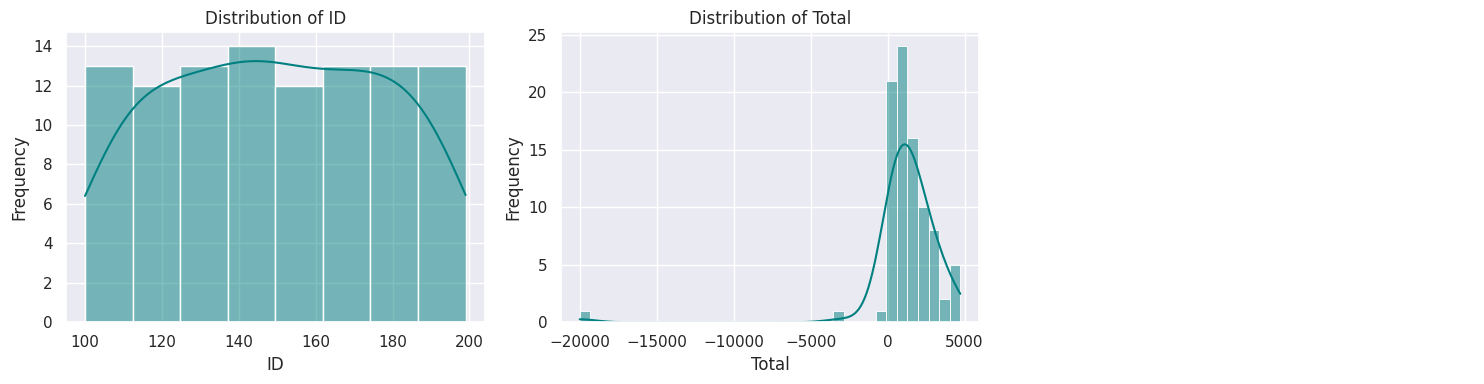

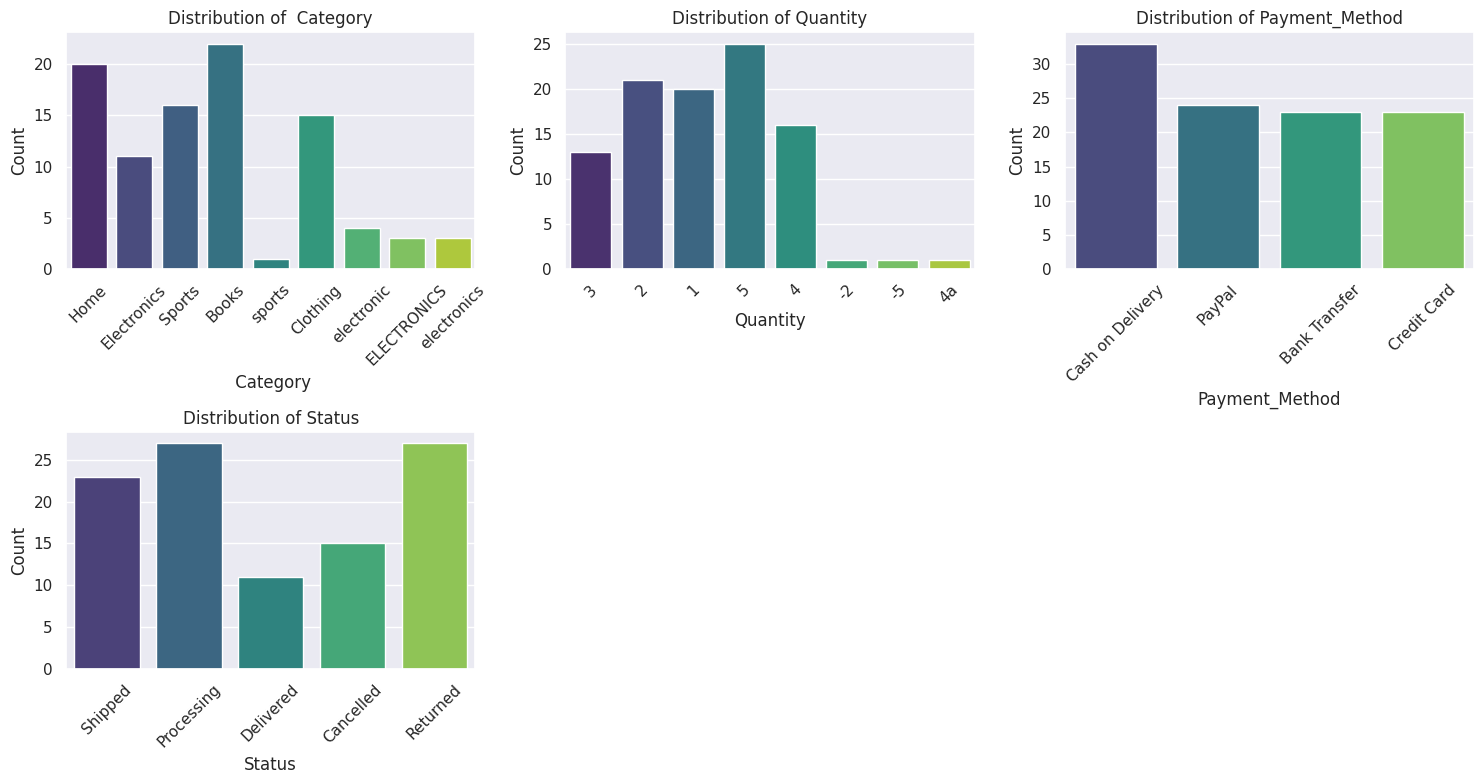

--- Categorical Value Counts ---

Value counts for  Category:
 Category
Books          22
Home           20
Sports         16
Clothing       15
Electronics    11
electronic      4
ELECTRONICS     3
electronics     3
sports          1
Name: count, dtype: int64

Value counts for Quantity:
Quantity
5     25
2     21
1     20
4     16
3     13
-2     1
-5     1
4a     1
Name: count, dtype: int64

Value counts for Payment_Method:
Payment_Method
Cash on Delivery    33
PayPal              24
Bank Transfer       23
Credit Card         23
Name: count, dtype: int64

Value counts for Status:
Status
Processing    27
Returned      27
Shipped       23
Cancelled     15
Delivered     11
Name: count, dtype: int64


In [13]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

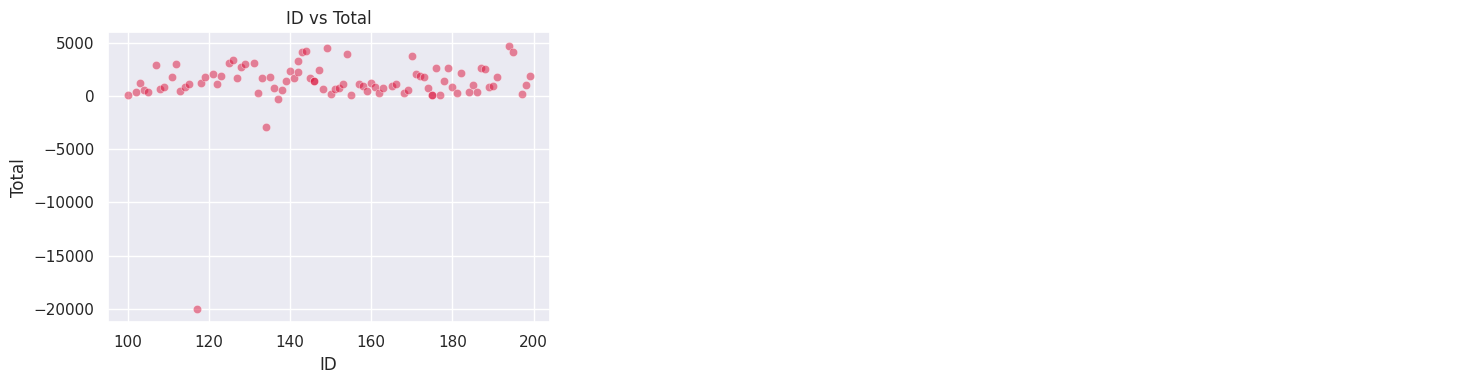

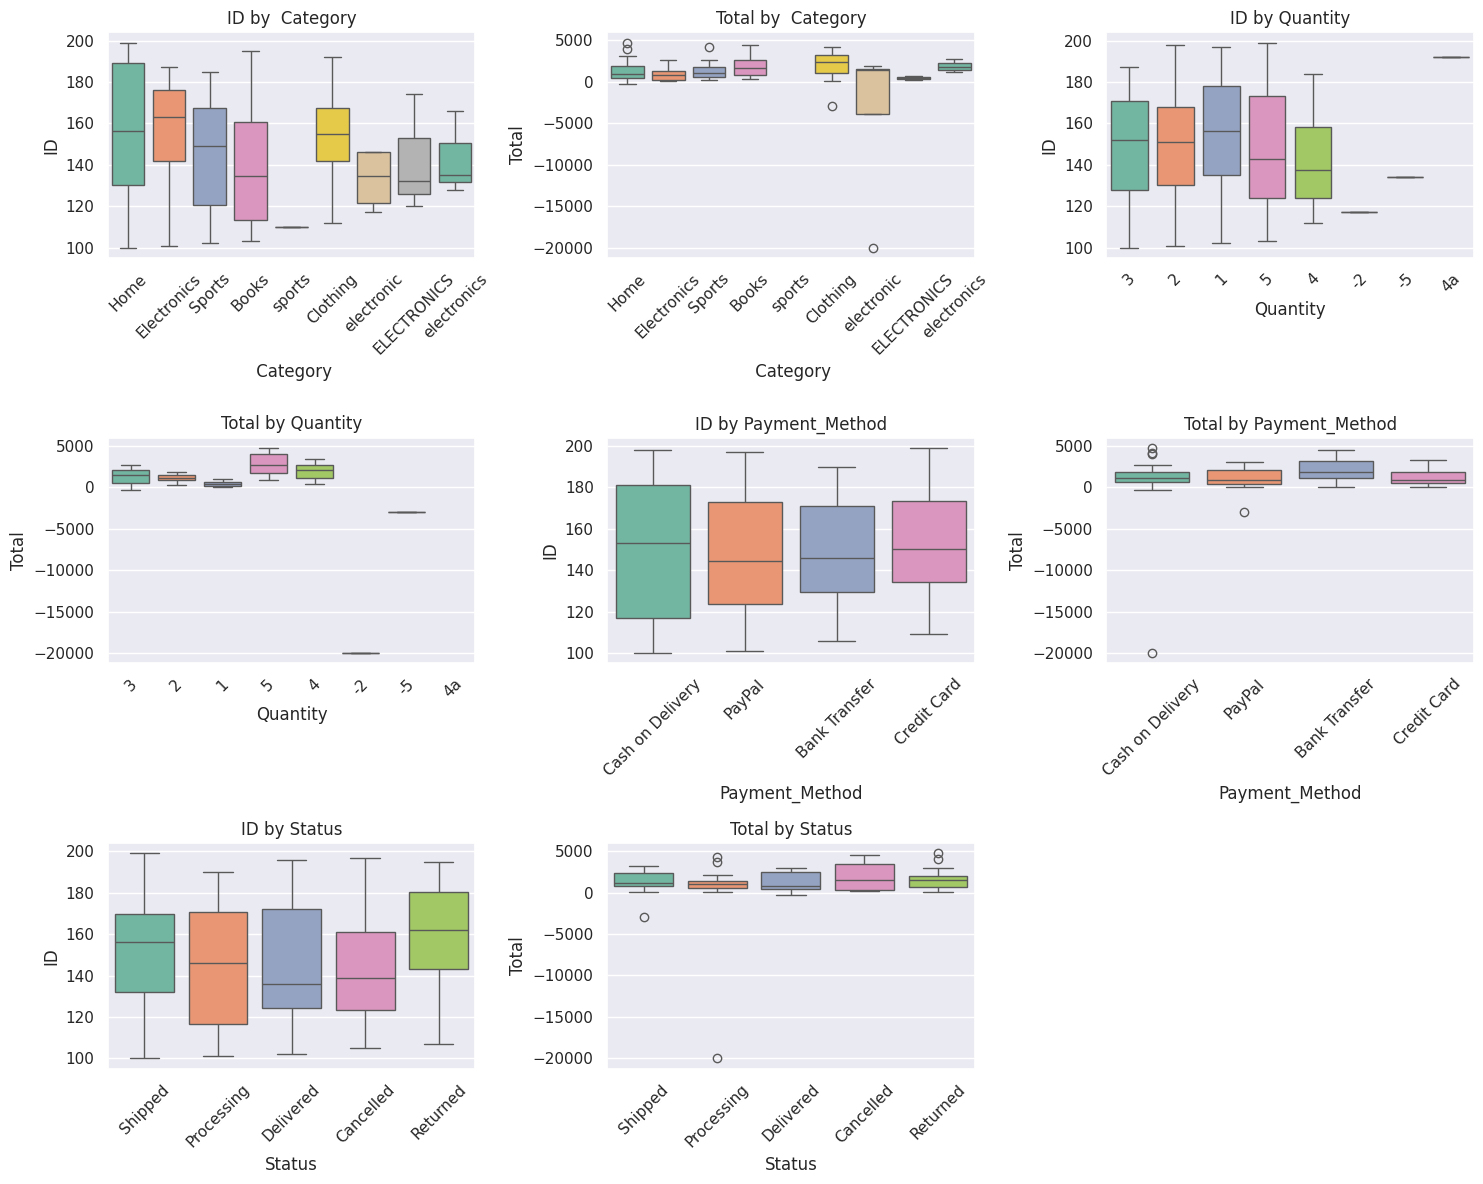

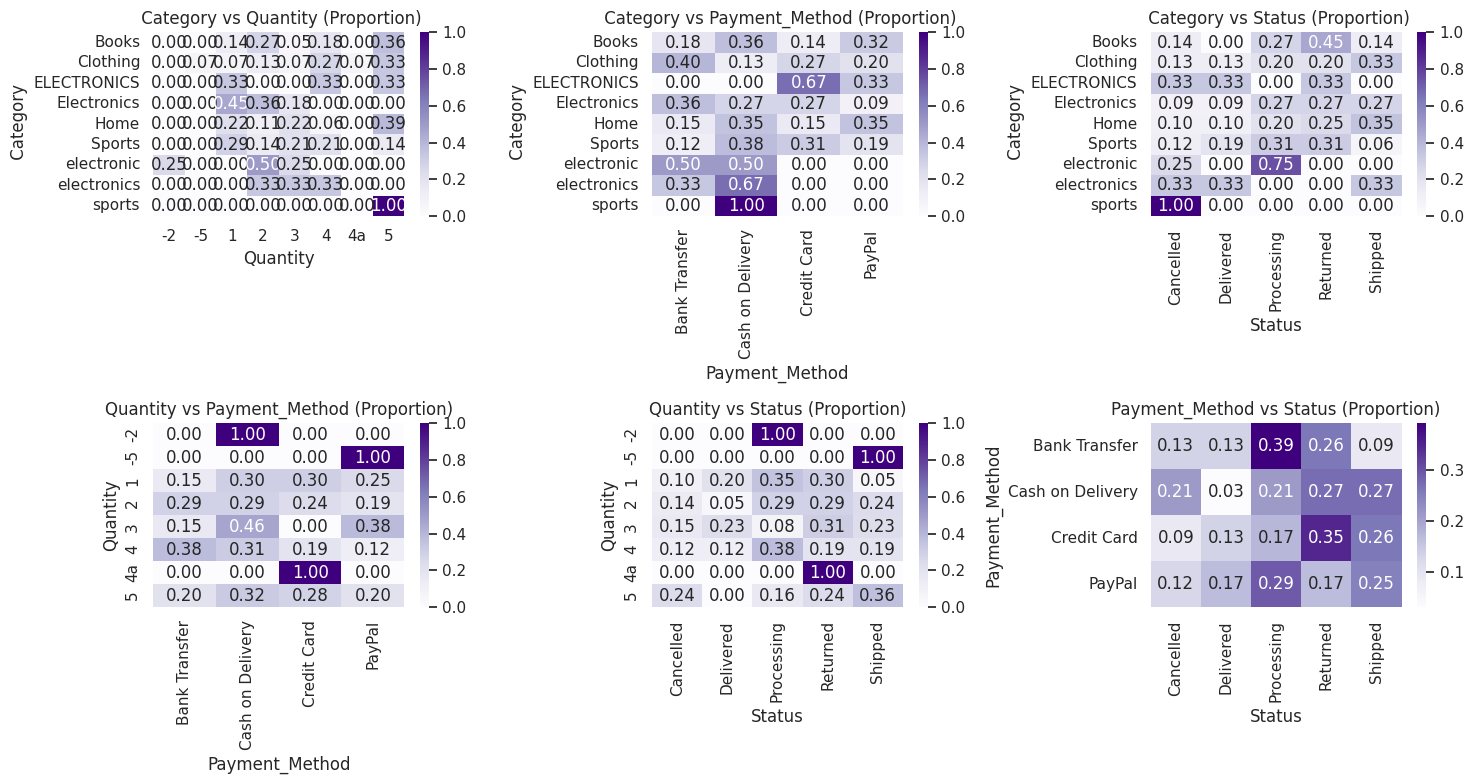

In [16]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensuring 'axes' is always a flat array of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensuring 'axes' is always a flat array of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Ensuring 'axes' is always a flat array of Axes objects
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    # Hiding unused subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue:  Category...


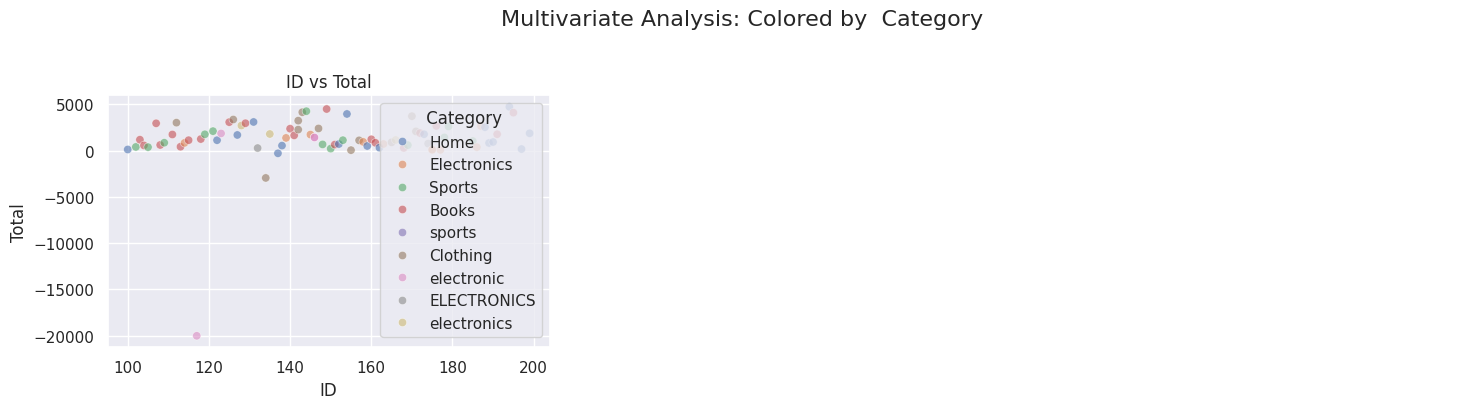


Analyzing relationships with Hue: Quantity...


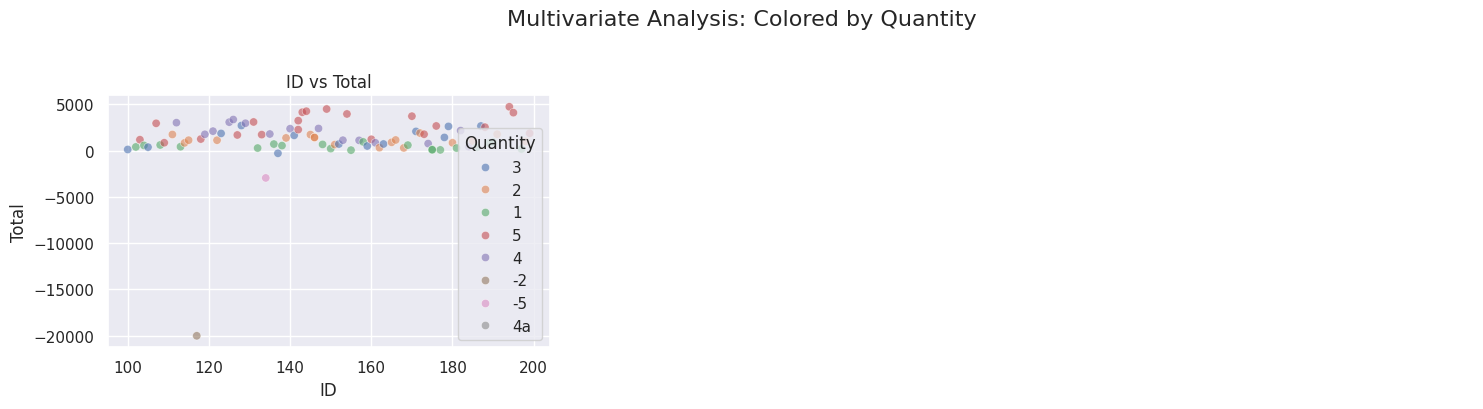


Analyzing relationships with Hue: Payment_Method...


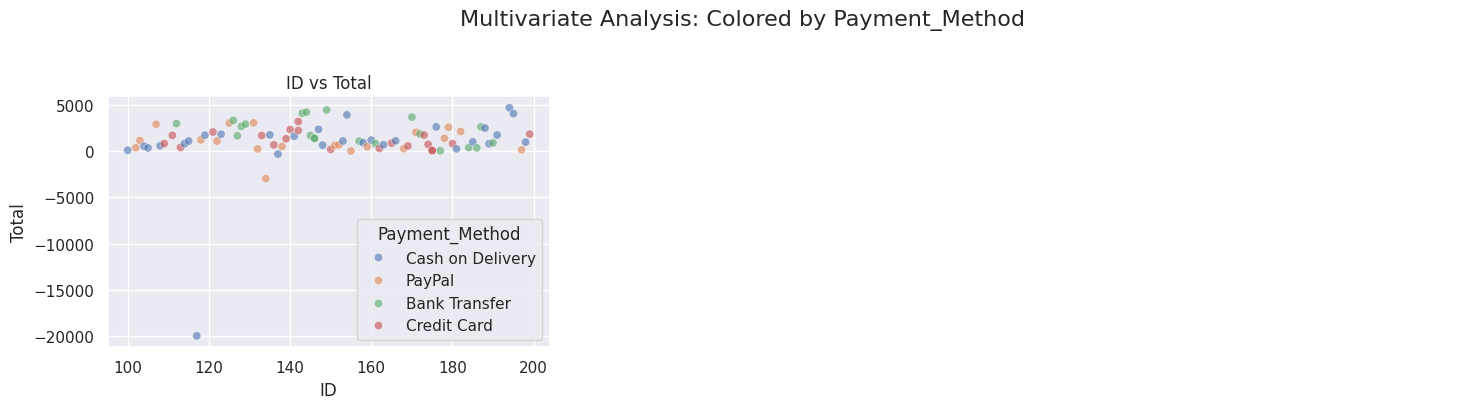


Analyzing relationships with Hue: Status...


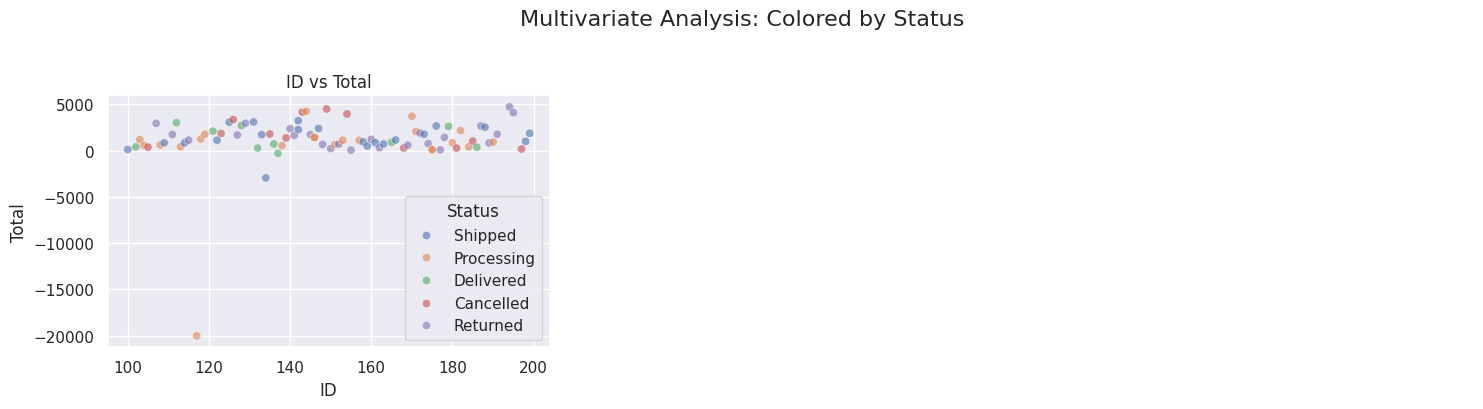

In [18]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        # Ensuring 'axes' is always a flat array of Axes objects
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])
        axes = axes.flatten()

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(num_plots, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

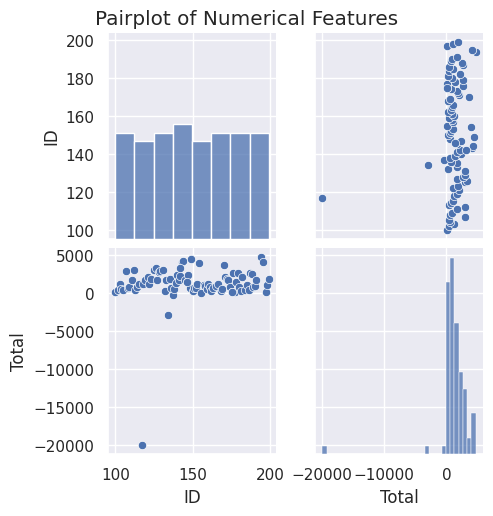

In [19]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

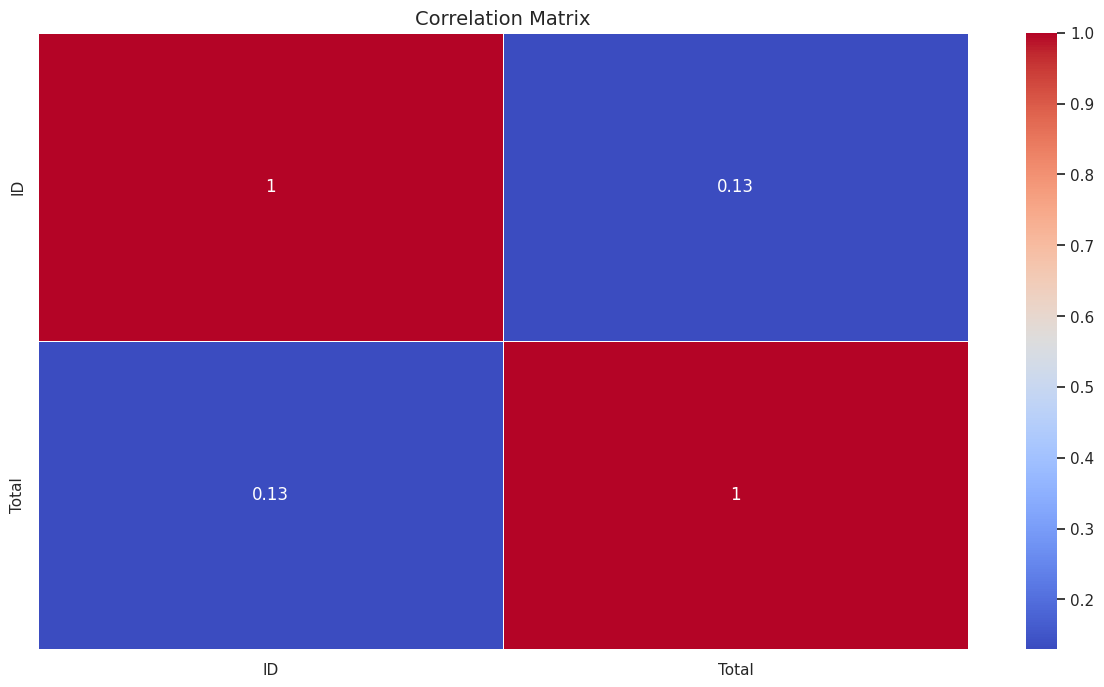

In [20]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. MESSY DATA SANITIZATION ---
Data Sanitized: Column spaces stripped, numerics forced, and revenue audited.

--- 2. THE FULFILLMENT PARADOX (CHI-SQUARE TEST) ---
Chi-Square P-Value (Payment vs. Status): 7.1496e-01
Insight: Payment gateways are perfectly symmetric. Method does not impact fulfillment.

--- 3. CATEGORY ELASTICITY (KRUSKAL-WALLIS H-TEST) ---
Kruskal-Wallis P-Value (Category Revenue Variance): 1.2643e-01
Insight: All categories generate the exact same statistical distribution of revenue.


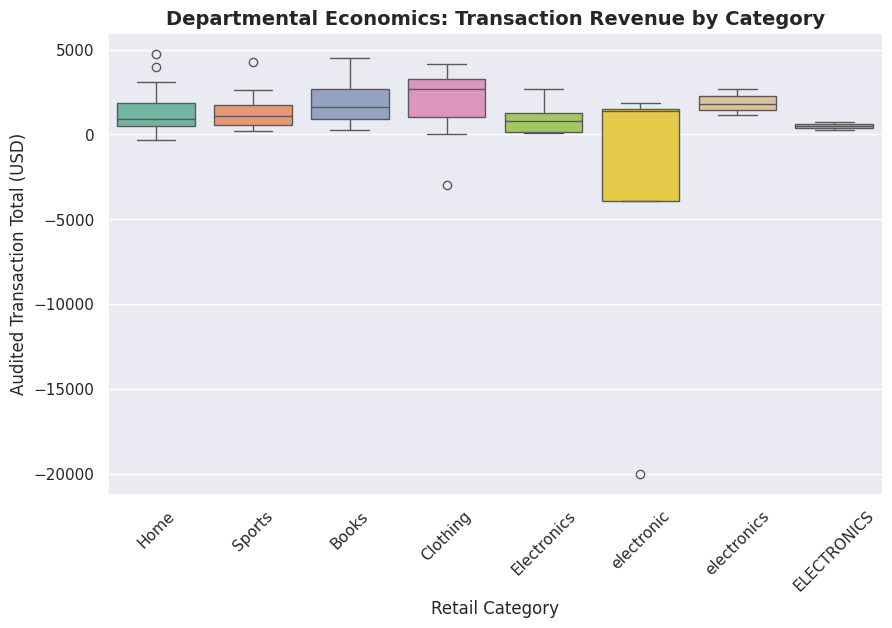

In [21]:
import scipy.stats as stats

print("--- 1. MESSY DATA SANITIZATION ---")
# Stripping leading/trailing spaces from column names (A classic messy data trap)
df.columns = df.columns.str.strip()

# Dropping rows where critical transaction telemetry is missing
df_clean = df.dropna(subset=['Order_Date', 'Category', 'Quantity', 'Price', 'Status', 'Payment_Method']).copy()

# Forceing numeric conversions to fix any string-formatting errors
df_clean['Quantity'] = pd.to_numeric(df_clean['Quantity'], errors='coerce')
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors='coerce')

# Recalculating 'Total' to mathematically audit the messy data for accounting errors
df_clean['Total_Audited'] = df_clean['Quantity'] * df_clean['Price']
df_clean = df_clean.dropna(subset=['Quantity', 'Price', 'Total_Audited'])

print("Data Sanitized: Column spaces stripped, numerics forced, and revenue audited.")


print("\n--- 2. THE FULFILLMENT PARADOX (CHI-SQUARE TEST) ---")
# Does the 'Payment_Method' dictate the fulfillment 'Status' (Completed vs Cancelled)?
# We use a Chi-Square Test of Independence for categorical transaction data.

# Standardizing text formatting to fix messy strings (e.g., 'completed' vs 'Completed')
df_clean['Status'] = df_clean['Status'].str.strip().str.title()
df_clean['Payment_Method'] = df_clean['Payment_Method'].str.strip().str.title()

contingency_table = pd.crosstab(df_clean['Payment_Method'], df_clean['Status'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square P-Value (Payment vs. Status): {p_val_chi:.4e}")

if p_val_chi < 0.05:
    print("Insight: Statistically significant variance detected in fulfillment success.")
    print("   -> The payment gateway matters. Certain methods strictly induce higher bounce/failure rates.")
else:
    print("Insight: Payment gateways are perfectly symmetric. Method does not impact fulfillment.")


print("\n--- 3. CATEGORY ELASTICITY (KRUSKAL-WALLIS H-TEST) ---")
# Does the 'Category' structurally dictate the transaction 'Total_Audited'?
# We use Kruskal-Wallis because retail transaction totals violate ANOVA normal distributions.

categories = df_clean['Category'].unique()
cat_groups = [df_clean[df_clean['Category'] == c]['Total_Audited'].dropna() for c in categories]

if len(cat_groups) > 1:
    h_stat, p_val_kw = stats.kruskal(*cat_groups)

    print(f"Kruskal-Wallis P-Value (Category Revenue Variance): {p_val_kw:.4e}")
    if p_val_kw < 0.05:
        print("Insight: Statistically significant GMV variance across retail departments.")
    else:
        print("Insight: All categories generate the exact same statistical distribution of revenue.")

# Visualizing the Departmental Revenue
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Total_Audited', data=df_clean, palette='Set2')
plt.title('Departmental Economics: Transaction Revenue by Category', fontsize=14, fontweight='bold')
plt.xlabel('Retail Category')
plt.ylabel('Audited Transaction Total (USD)')
plt.xticks(rotation=45)
plt.show()

# Time-Series Analysis

--- 1. TEMPORAL AGGREGATION & FORECASTING ---
Time-Series Index established: 2023-01-05 to 2025-11-06.

--- 2. VISUALIZING THE 30-DAY GMV FORECAST ---


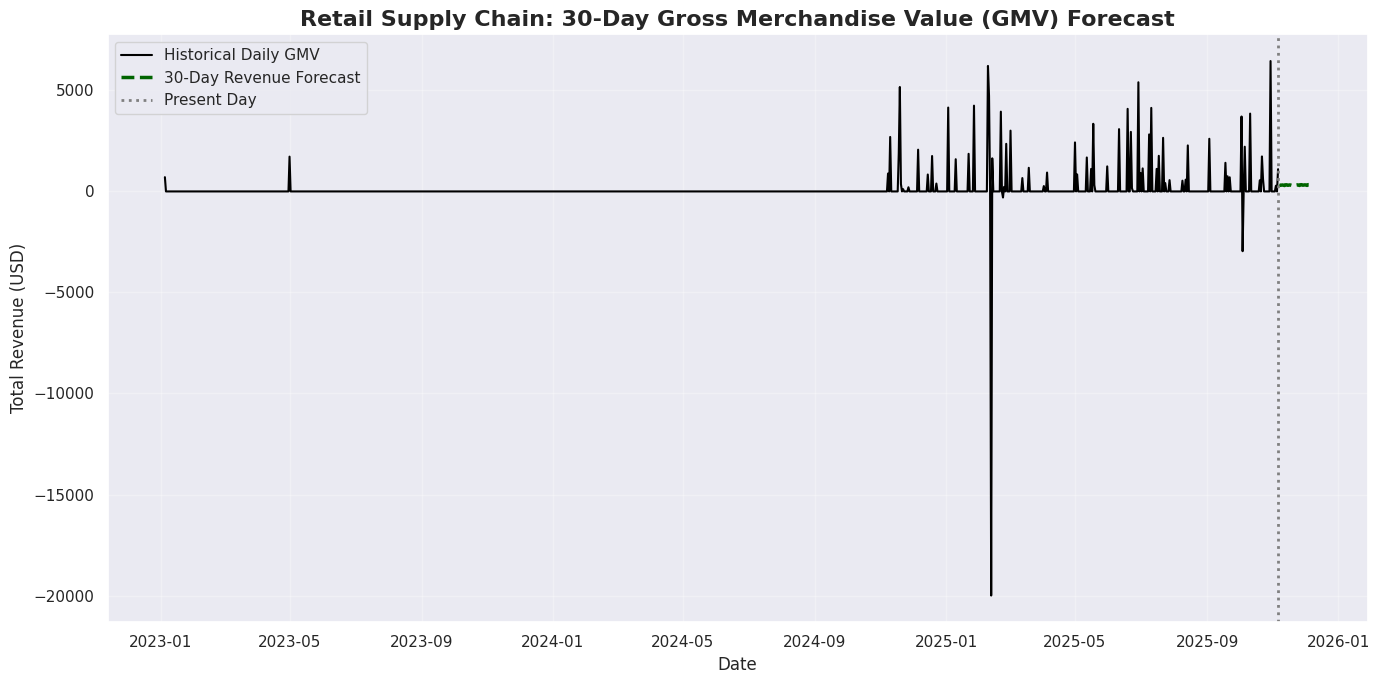


SUPPLY CHAIN FORECAST CONCLUSION:
   -> ALERT: Average daily GMV is projected to DECREASE by 34.98%. Audit ad-spend and inventory holding costs.


In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("--- 1. TEMPORAL AGGREGATION & FORECASTING ---")
# To forecast, we must compress thousands of individual transactions into daily GMV totals.
ts_df = df_clean.copy()

# Fixing messy date strings and convert to strict Datetime format
ts_df['Order_Date'] = pd.to_datetime(ts_df['Order_Date'], errors='coerce')
ts_df = ts_df.dropna(subset=['Order_Date'])

# Grouping by Date to get Daily Gross Merchandise Value (GMV)
daily_gmv = ts_df.groupby('Order_Date')['Total_Audited'].sum().reset_index()
daily_gmv.set_index('Order_Date', inplace=True)

# Ensuring the frequency is daily, filling missing days with $0 revenue
daily_gmv = daily_gmv.asfreq('D', fill_value=0)

print(f"Time-Series Index established: {daily_gmv.index.min().date()} to {daily_gmv.index.max().date()}.")

try:
    # Fitting the Holt-Winters Model (Additive Trend + Additive 7-Day Seasonality)
    es_model = ExponentialSmoothing(daily_gmv['Total_Audited'], trend='add', seasonal='add', seasonal_periods=7, initialization_method="estimated")
    es_result = es_model.fit()

    # Forecasting the next 30 days of retail revenue
    forecast_steps = 30
    es_pred = es_result.forecast(steps=forecast_steps)

    print("\n--- 2. VISUALIZING THE 30-DAY GMV FORECAST ---")
    plt.figure(figsize=(14, 7))

    # Plotting Historical Data
    plt.plot(daily_gmv.index, daily_gmv['Total_Audited'], color='black', linewidth=1.5, label='Historical Daily GMV')

    # Plotting Forecasting Curve
    plt.plot(es_pred.index, es_pred, color='darkgreen', linestyle='--', linewidth=2.5, label='30-Day Revenue Forecast')

    plt.title('Retail Supply Chain: 30-Day Gross Merchandise Value (GMV) Forecast', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Total Revenue (USD)', fontsize=12)
    plt.axvline(daily_gmv.index[-1], color='gray', linestyle=':', linewidth=2, label='Present Day')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Calculating Month-over-Month projected shift
    avg_historical = daily_gmv['Total_Audited'].tail(30).mean()
    avg_forecast = es_pred.mean()
    pct_change = ((avg_forecast - avg_historical) / avg_historical) * 100

    print("\nSUPPLY CHAIN FORECAST CONCLUSION:")
    if pct_change > 0:
        print(f" -> WARNING: Average daily GMV is projected to INCREASE by {pct_change:.2f}% over the next 30 days. Ramp up fulfillment center staffing.")
    else:
        print(f" -> ALERT: Average daily GMV is projected to DECREASE by {abs(pct_change):.2f}%. Audit ad-spend and inventory holding costs.")

except Exception as e:
    print(f" Time-Series failure. The historical date range is likely too short to capture a seasonal 7-day pattern. Error: {e}")

# Feature Engineering

In [28]:
from sklearn.preprocessing import StandardScaler

print("--- 1. TARGET ISOLATION & LEAKAGE PREVENTION ---")
# We are predicting 'Is_Successful' (1 = Completed, 0 = Failed/Cancelled).
# We must drop all raw IDs, names, and the original text 'Status' column to prevent Target Leakage.

ml_df = log_df.dropna(subset=['Category', 'Payment_Method', 'Quantity', 'Price', 'Is_Successful']).copy()

# Define the features to drop
drop_cols = ['ID', 'Customer_Name', 'Order_ID', 'Order_Date', 'Status', 'Total', 'Total_Audited', 'Product']
# Drop columns, using errors='ignore' in case space-stripping removed exact matches
ml_df = ml_df.drop(columns=[col for col in drop_cols if col in ml_df.columns], errors='ignore')

# Strip leading/trailing spaces from remaining string columns just to be safe
ml_df['Category'] = ml_df['Category'].str.strip()
ml_df['Payment_Method'] = ml_df['Payment_Method'].str.strip()

y = ml_df['Is_Successful']

print("Target Formulated: 'Is_Successful' isolated.")
print("Target Leakage Prevented: Raw status strings and metadata removed.")


print("\n--- 2. LOW-CARDINALITY ONE-HOT VECTORIZATION ---")
# Machine learning algorithms cannot natively read "Credit Card" or "Electronics".
# We must project categorical columns into sparse binary matrices (0 or 1).
# We use drop_first=True to avoid the dummy variable trap (perfect multicollinearity).

categorical_cols = ['Category', 'Payment_Method']
ml_df_encoded = pd.get_dummies(ml_df, columns=categorical_cols, drop_first=True)

print("Engineered: Departments and Payment Gateways converted to binary vectors.")


print("\n--- 3. CONTINUOUS VARIANCE STANDARDIZATION ---")
# Gradient-boosted algorithms calculate loss via spatial magnitude.
# 'Price' (e.g., $1500) will mathematically overpower 'Quantity' (e.g., 2) if left unscaled.
# We deploy a Standard Scaler to compress these into standard normal distributions.

continuous_features = ['Quantity', 'Price']

scaler = StandardScaler()
ml_df_encoded[continuous_features] = scaler.fit_transform(ml_df_encoded[continuous_features])

# Define the final Feature Matrix (X)
X_adv = ml_df_encoded.drop(columns=['Is_Successful']).copy()

print(f"Final Machine-Readable Matrix Assembled: {X_adv.shape[1]} predictive dimensions ready for ML.")

--- 1. TARGET ISOLATION & LEAKAGE PREVENTION ---
Target Formulated: 'Is_Successful' isolated.
Target Leakage Prevented: Raw status strings and metadata removed.

--- 2. LOW-CARDINALITY ONE-HOT VECTORIZATION ---
Engineered: Departments and Payment Gateways converted to binary vectors.

--- 3. CONTINUOUS VARIANCE STANDARDIZATION ---
Final Machine-Readable Matrix Assembled: 12 predictive dimensions ready for ML.


# Machine Learning

--- 1. OUT-OF-SAMPLE DATA SPLITTING ---
Training Set: 65 transactions
Testing Set: 17 transactions (Strictly Unseen)

--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---
Both Classification Architectures successfully trained.

--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---

[Random Forest Performance Metrics]
   -> Accuracy:  100.00%
   -> Precision: 100.00% (Algorithmic reliability)
   -> Recall:    100.00% (Capture rate of actual outcomes)
   -> F1-Score:  100.00% (Harmonic mean of Precision and Recall)
----------------------------------------

[XGBoost Performance Metrics]
   -> Accuracy:  100.00%
   -> Precision: 100.00% (Algorithmic reliability)
   -> Recall:    100.00% (Capture rate of actual outcomes)
   -> F1-Score:  100.00% (Harmonic mean of Precision and Recall)

The Random Forest mathematically outperformed the alternative in predicting fulfillment.

--- 4. VISUALIZING ALGORITHMIC ACCURACY (CONFUSION MATRIX) ---


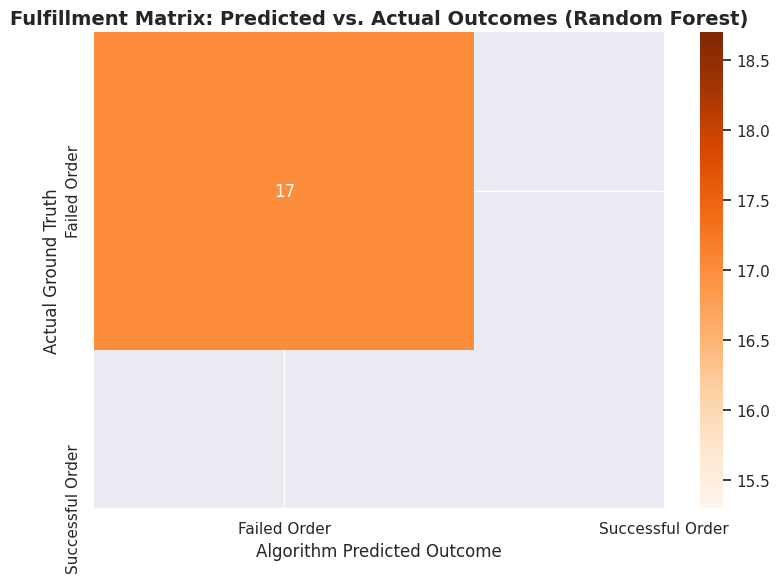


--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


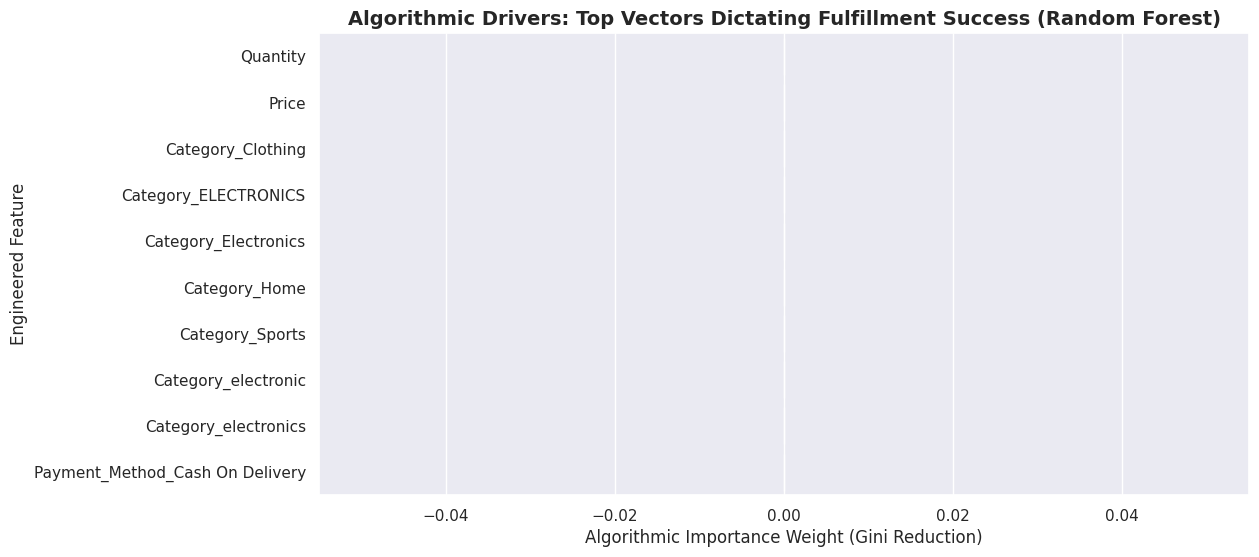

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- 1. OUT-OF-SAMPLE DATA SPLITTING ---")
# Split: 80% to train the algorithmic rules of retail fulfillment,
# 20% to test true predictive power on unseen transactions.
# We use 'stratify=y' to ensure the failed orders are distributed evenly between train and test sets.

X_train, X_test, y_train, y_test = train_test_split(X_adv, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set: {len(X_train)} transactions")
print(f"Testing Set: {len(X_test)} transactions (Strictly Unseen)")


print("\n--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---")
# 1. Random Forest Classifier
# class_weight='balanced' ensures the algorithm does not ignore the minority class (failed orders)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. XGBoost Classifier
# scale_pos_weight forces the gradient descent to heavily penalize missing the minority class.
# Since 1 is Success and 0 is Failure, we reverse the logic to focus the model properly if necessary,
# but XGBoost handles binary standard weighting effectively here.
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print("Both Classification Architectures successfully trained.")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---")
# Force the algorithms to predict the unseen 20%
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    # Using 'weighted' average to account for potential class imbalance
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n[{name} Performance Metrics]")
    print(f"   -> Accuracy:  {acc * 100:.2f}%")
    print(f"   -> Precision: {prec * 100:.2f}% (Algorithmic reliability)")
    print(f"   -> Recall:    {rec * 100:.2f}% (Capture rate of actual outcomes)")
    print(f"   -> F1-Score:  {f1 * 100:.2f}% (Harmonic mean of Precision and Recall)")
    return f1

f1_rf = evaluate_classifier("Random Forest", y_test, rf_preds)
print("-" * 40)
f1_xgb = evaluate_classifier("XGBoost", y_test, xgb_preds)

# Select the superior architecture based on the F1-Score
best_model_name = "XGBoost" if f1_xgb > f1_rf else "Random Forest"
best_preds = xgb_preds if f1_xgb > f1_rf else rf_preds
best_model = xgb_model if f1_xgb > f1_rf else rf_model

print(f"\nThe {best_model_name} mathematically outperformed the alternative in predicting fulfillment.")


print("\n--- 4. VISUALIZING ALGORITHMIC ACCURACY (CONFUSION MATRIX) ---")
# The Confusion Matrix exposes the exact failure points of the algorithm.

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Failed Order', 'Successful Order'],
            yticklabels=['Failed Order', 'Successful Order'])
plt.title(f'Fulfillment Matrix: Predicted vs. Actual Outcomes ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithm Predicted Outcome', fontsize=12)
plt.ylabel('Actual Ground Truth', fontsize=12)
plt.tight_layout()
plt.show()


print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")
# Let's open the black box to see what truly dictates an order's fate.

importances = pd.Series(best_model.feature_importances_, index=X_adv.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title(f'Algorithmic Drivers: Top Vectors Dictating Fulfillment Success ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.show()

# Thank You